# **Statistical Arbitrage - Pairs Trading**

## **Theory**

### **From Arbitrage to Statistical Arbitrage**

At its core, **arbitrage** means exploiting price discrepancies between identical or similar assets to earn a *risk-free* profit.
In reality, truly risk-free opportunities are rare and short-lived. So, traders began extending the idea probabilistically: instead of guaranteed profits, they seek **expected** profits with **controlled risk** - this is **statistical arbitrage (stat-arb)**.

**Statistical arbitrage** is a quantitative trading strategy that uses statistical models to identify mispricings between related securities. It’s based not on perfect replication (as in classical arbitrage) but on the statistical expectation that price relationships will revert to some equilibrium over time. 
The key ingredients are:

* **A model** for the “fair” relationship between asset prices.
* **A deviation measure** (how far the actual prices stray from that model).
* **A trading rule** to exploit mean reversion.

The simplest and most famous form of stat-arb is **pairs trading**.

---

### **Pairs Trading: The Intuition**

In **pairs trading**, we pick two assets (say, two stocks in the same sector) whose prices tend to move together - perhaps Shell and BP.

1. We monitor their *relative price* - for example, the price difference or a linear combination $S_t = P_{1,t} - \beta P_{2,t}$.
2. When this spread deviates “too far” from its historical average, we bet on *convergence*:

   * Go long the underperformer (buy it).
   * Go short the outperformer (sell it).
3. When the spread returns to normal, we close both positions, ideally making a profit.

This relies on **mean reversion** - the assumption that relative prices don’t drift apart indefinitely but fluctuate around some equilibrium relationship.

But how can we **verify** whether two price series are genuinely tied together in the long run?
That’s where **cointegration** comes in.

---

### **Cointegration: The Statistical Foundation**

Most financial time series, like stock prices, are **non-stationary** - they follow something like a random walk.
That means they can drift arbitrarily far from their initial value, and standard correlation is unreliable because the level of the series doesn’t have a stable mean or variance.

However, sometimes two non-stationary series move *together* in such a way that a particular linear combination is **stationary** (mean-reverting).
Formally, if:
$$
X_t \sim I(1), \quad Y_t \sim I(1),
$$
but there exists some ($\beta$) such that:
$$
Z_t = Y_t - \beta X_t \sim I(0),
$$
then ($X_t$) and ($Y_t$) are **cointegrated** with cointegrating vector $(1, -\beta)$.

In words: although each price series wanders, their long-run equilibrium relation keeps them tethered.
The deviation $Z_t$ is the “spread” - the variable we expect to revert to its mean. This is the signal that drives a pairs trade.

---

### **Testing and Modeling Cointegration**

Several tools exist to detect and exploit cointegration:

* **Engle–Granger two-step test**:

  1. Regress $Y_t$ on $X_t$ to estimate $\hat{\beta}$.
  2. Test residuals $Z_t = Y_t - \hat{\beta} X_t$ for stationarity using, e.g., the Augmented Dickey-Fuller (ADF) test.

* **Johansen test**:
  For multiple assets, it finds the rank and cointegrating relationships within a vector error-correction model (VECM).

If cointegration holds, we can model the short-run deviations using:
$$
\Delta Y_t = \alpha (Y_{t-1} - \beta X_{t-1}) + \varepsilon_t,
$$
where $\alpha$ measures the **speed of adjustment** back to equilibrium.

---

### **From Cointegration to Trading**

Once we have a stationary spread $Z_t = Y_t - \beta X_t$, we treat it as a *mean-reverting process*, often modeled as:
$$
dZ_t = \kappa (\mu - Z_t)dt + \sigma dW_t,
$$
where:

* $\kappa$: mean-reversion speed,
* $\mu$: long-run mean (usually zero),
* $\sigma$: volatility of the spread.

The trading rule is straightforward:

* Go **long** when $Z_t$ is below its mean (expect it to rise).
* Go **short** when $Z_t$ is above its mean (expect it to fall).
* Close the position when $Z_t$ reverts.

Profit comes not from predicting direction, but from betting on *relative convergence*.

In [1]:
# Import libaries -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from arch.unitroot import ADF
from arch.unitroot import PhillipsPerron
from itertools import combinations


## **Data**

In [2]:
# Import and prepare data -----

# Price data
dfPRICES = pd.read_csv('data/DJGT_prices.csv', index_col=0, parse_dates=True)

# Extract stock names 
lSTOCKS = dfPRICES.columns.tolist()

# Number of observations
iOBS = len(dfPRICES)

# Log prices
dfLOGPRICES = np.log(dfPRICES)

# Consituents info
dfCONSTITUENTS = pd.read_csv('data/DJGT_constituents.csv', index_col=0)


## **Engle–Granger Two-step Cointegration Test**

In [3]:
# Cointegration test for stock pairs –––––

# Initilize lists to store regression rows
lREG_ROWS = []
# Initilize dictionaries to store spreads and fitted values
dSPREAD = {}
dFITTED = {}

# Iterate through all possible pairs of stocks
for Y, X in combinations(lSTOCKS, 2):

    # Step I. Regression ---

    # Extract log price series for the pair
    sY = dfLOGPRICES[Y].to_numpy()
    sX = dfLOGPRICES[X].to_numpy()

    # OLS Regression: sY = ALPHA + BETA * sX + RESID
    sX = np.column_stack([np.ones_like(sX), sX])
    fALPHA, fBETA = np.linalg.lstsq(sX, sY, rcond=None)[0]

    # Calculate fitted values and residuals
    sFITTED = sX @ np.array([fALPHA, fBETA])
    sRESID = sY - sFITTED

    # Calculate R-squared
    fSS_RES = float(np.dot(sRESID, sRESID))
    sY_CENTERED = sY - sY.mean()
    fSS_TOT = float(np.dot(sY_CENTERED, sY_CENTERED))
    fR2 = np.nan if fSS_TOT == 0.0 else 1.0 - fSS_RES / fSS_TOT

    # lREG_ROWS.append({"Y": Y, "X": X, "ALPHA": float(fALPHA), "BETA": float(fBETA), "R2": fR2})

    strKEY = f"{Y}_on_{X}"
    dSPREAD[strKEY] = pd.Series(sRESID, index=dfLOGPRICES.index)
    dFITTED[strKEY] = pd.Series(sFITTED, index=dfLOGPRICES.index)


    # Plot of regression results
    # plt.figure(figsize=(10, 5), dpi=100)
    # plt.plot(dfREG_SPREAD[f"{Y}_on_{X}"], label=Y)
    # plt.plot(dfREG_FITTED[f"{Y}_on_{X}"], linestyle="--", label=f"ALPHA + BETA * {X}")
    # plt.title(f"OLS regression (training): {Y} on {X}")
    # plt.xlabel("Intraday observation index")
    # plt.ylabel("Log Price")
    # plt.legend(loc="best")
    # plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # # plt.show()
    # plt.savefig(f"figs/ols-regression-{Y}-on-{X}.png")
    # plt.close()

    # Step II. Spread Stationarity ---

    # Augmented Dickey-Fuller test
    testADF = ADF(sRESID)
    fADF_PVALUE = testADF.pvalue
    # Phillips-Perron test
    testPP = PhillipsPerron(sRESID)
    fPP_PVALUE = testPP.pvalue

    # Store results in the regression rows
    lREG_ROWS.append({"Y": Y, "X": X, "ALPHA": float(fALPHA), "BETA": float(fBETA), "R2": fR2, "ADF_pvalue": fADF_PVALUE, "PP_pvalue": fPP_PVALUE})


    # Plot spread
    # plt.figure(figsize=(10, 5), dpi=200)
    # plt.plot(dSPREAD[strKEY].reset_index(drop=True), label="SPREAD")
    # plt.title("Spread (OLS residual)")
    # plt.xlabel("Intraday observation index")
    # plt.ylabel("Spread")
    # plt.legend(loc="best")
    # plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # plt.show()

# Build DataFrames for regression results, spreads, and fitted values
dfREG_RESULTS = pd.DataFrame.from_records(lREG_ROWS, columns=["Y", "X", "ALPHA", "BETA", "R2", "ADF_pvalue", "PP_pvalue"])
dfREG_SPREAD = pd.DataFrame(dSPREAD)
dfREG_FITTED = pd.DataFrame(dFITTED)


### **Visualization**

In [12]:
# Create a DataFrame for orderin pairs based on cointegration test results
dfREG_RESULTS["ORDER"] = dfREG_RESULTS[["ADF_pvalue", "PP_pvalue"]].mean(axis=1)
dfREG_RESULTS = dfREG_RESULTS.sort_values("ORDER", ascending=False).reset_index(drop=True)

KeyboardInterrupt: 

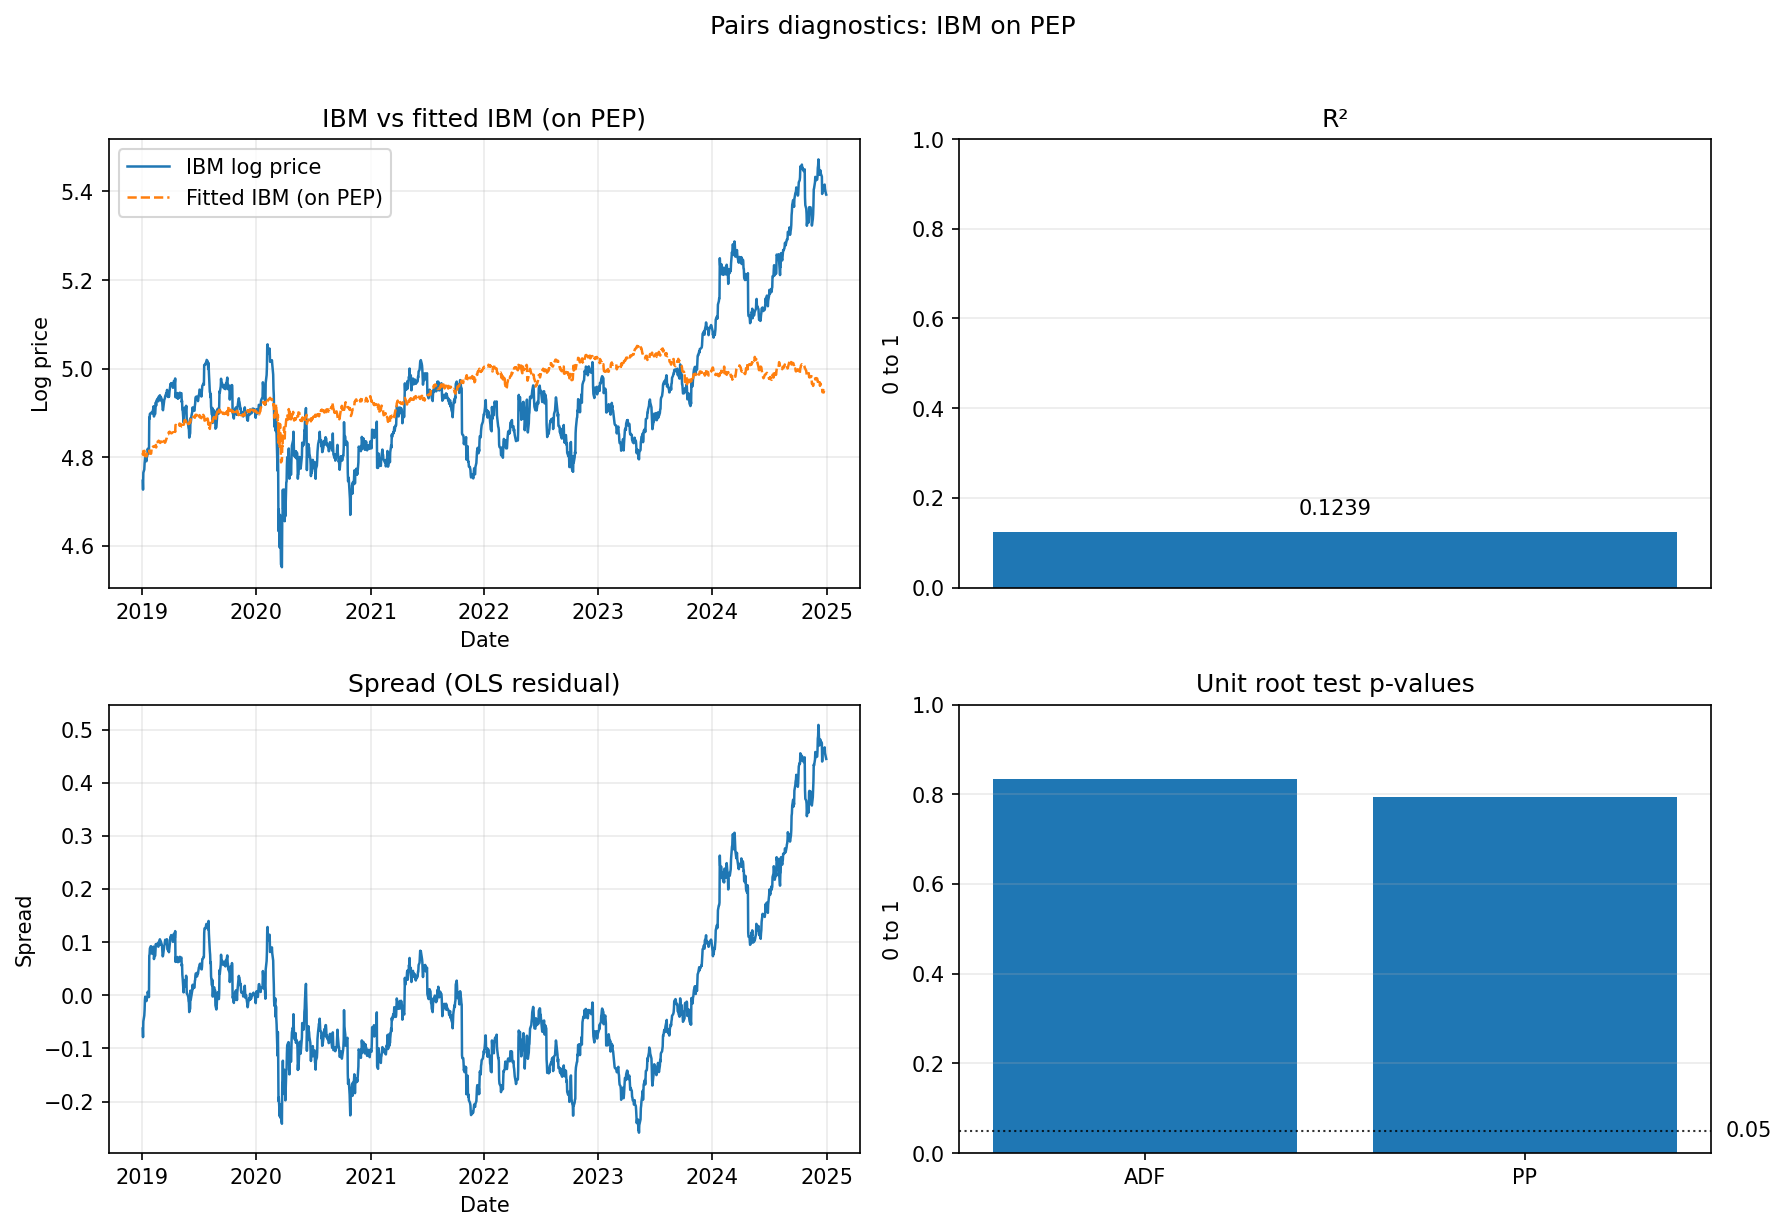

In [14]:
# Create 2x2 diagnostic plots for every stock pair and save to /figs



# Iterate over all regression results (one row per pair)
for _, sROW in dfREG_RESULTS.iterrows():
    sY = sROW["Y"]
    sX = sROW["X"]
    strKEY = f"{sY}_on_{sX}"

    # Pull series needed for plots
    # 11: Y logprice and regressed (fitted) Y on X
    sY_logprices = dfLOGPRICES[sY]
    sY_fitted = dfREG_FITTED[strKEY]

    # 21: Spread (residuals)
    sSpread = dfREG_SPREAD[strKEY]

    # 12: R2
    fR2 = float(sROW["R2"]) if pd.notna(sROW["R2"]) else np.nan

    # 22: p-values
    fADF_PVALUE = float(sROW["ADF_pvalue"]) if pd.notna(sROW["ADF_pvalue"]) else np.nan
    fPP_PVALUE = float(sROW["PP_pvalue"]) if pd.notna(sROW["PP_pvalue"]) else np.nan


    # --- Build 2x2 figure
    fig, ax = plt.subplots(2, 2, figsize=(12, 8), dpi=150)

    # 11 (top-left): Y logprice + fitted Y (regressed on X)
    ax[0, 0].plot(sY_logprices.index, sY_logprices.values, label=f"{sY_logprices.name} log price", linewidth=1.2)
    ax[0, 0].plot(sY_fitted.index, sY_fitted.values, label=f"Fitted {sY_logprices.name} (on {sX})", linewidth=1.2, linestyle="--")
    ax[0, 0].set_title(f"{sY_logprices.name} vs fitted {sY_logprices.name} (on {sX})")
    ax[0, 0].set_xlabel("Date")
    ax[0, 0].set_ylabel("Log price")
    ax[0, 0].grid(True, alpha=0.25)
    ax[0, 0].legend(loc="best")

    # 12 (top-right): single bar for R2 (0..1)
    r2_bar = 0.0 if np.isnan(fR2) else max(0.0, min(1.0, fR2))
    ax[0, 1].bar([0], [r2_bar], width=0.6)
    ax[0, 1].set_ylim(0, 1)
    ax[0, 1].set_xticks([])
    ax[0, 1].set_title("R²")
    ax[0, 1].set_ylabel("0 to 1")
    ax[0, 1].grid(True, axis="y", alpha=0.25)
    ax[0, 1].text(0, r2_bar + 0.03, f"{fR2:.4f}" if not np.isnan(fR2) else "NaN", ha="center", va="bottom")

    # 21 (bottom-left): Spread
    ax[1, 0].plot(sSpread.index, sSpread.values, linewidth=1.2)
    ax[1, 0].set_title("Spread (OLS residual)")
    ax[1, 0].set_xlabel("Date")
    ax[1, 0].set_ylabel("Spread")
    ax[1, 0].grid(True, alpha=0.25)

    # 22 (bottom-right): p-values (ADF + PP) (0..1)
    pvals = [
        0.0 if np.isnan(fADF_PVALUE) else max(0.0, min(1.0, fADF_PVALUE)),
        0.0 if np.isnan(fPP_PVALUE) else max(0.0, min(1.0, fPP_PVALUE)),
    ]
    ax[1, 1].bar(["ADF", "PP"], pvals)
    ax[1, 1].set_ylim(0, 1)
    ax[1, 1].set_title("Unit root test p-values")
    ax[1, 1].set_ylabel("0 to 1")
    ax[1, 1].grid(True, axis="y", alpha=0.25)

    # Optional: common significance threshold line
    ax[1, 1].axhline(0.05, color="black", linewidth=1.0, linestyle=":", alpha=0.8)
    ax[1, 1].text(1.02, 0.05, "0.05", transform=ax[1, 1].get_yaxis_transform(), va="center")

    # Finalize + save
    fig.suptitle(f"Pairs diagnostics: {sY_logprices.name} on {sX}", y=1.02)
    fig.tight_layout()
    fig.savefig(f"figs/{_}-pairs-{sY_logprices.name}-on-{sX}.png", bbox_inches="tight")
    plt.close(fig)



## **Johansen Cointegration Test**
>**Work In Progress**

## **Trading**